In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from pathlib import Path

In [2]:
DATA_PATH = Path("../dataset/placement_dataset.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", df.shape)

Dataset loaded: (4000, 22)


In [3]:
placement_target = "placement_status"
career_target = "career_group"

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != placement_target]
cat_cols = [c for c in df.columns if c not in num_cols + [placement_target, career_target, "career_interest"]]

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [4]:
try:
    placement_model = joblib.load("placement_model.pkl")
    career_model = joblib.load("career_model.pkl")
    print("Loaded existing models")
except:
    print("Models not found, retraining temporary versions...")

    le = LabelEncoder()
    df[career_target] = le.fit_transform(df[career_target])

    X = df.drop([placement_target, career_target, "career_interest"], axis=1)
    y_place = df[placement_target]
    y_career = df[career_target]

    X_train, X_test, y_train_p, y_test_p = train_test_split(
        X, y_place, test_size=0.2, random_state=42, stratify=y_place
    )
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_career, test_size=0.2, random_state=42, stratify=y_career
    )

    placement_model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000))
    ])
    placement_model.fit(X_train, y_train_p)

    career_model = Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            objective='multi:softprob',
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ])
    career_model.fit(X_train_c, y_train_c)

    joblib.dump(placement_model, "placement_model.pkl")
    joblib.dump(career_model, "career_model.pkl")

Models not found, retraining temporary versions...


In [5]:
X_sample = df.sample(300, random_state=42).drop(
    [placement_target, career_target, "career_interest"], axis=1
)

X_trans_place = placement_model["prep"].transform(X_sample)
X_trans_career = career_model["prep"].transform(X_sample)

feature_names = list(placement_model["prep"].get_feature_names_out())


SHAP Analysis - Placement Model


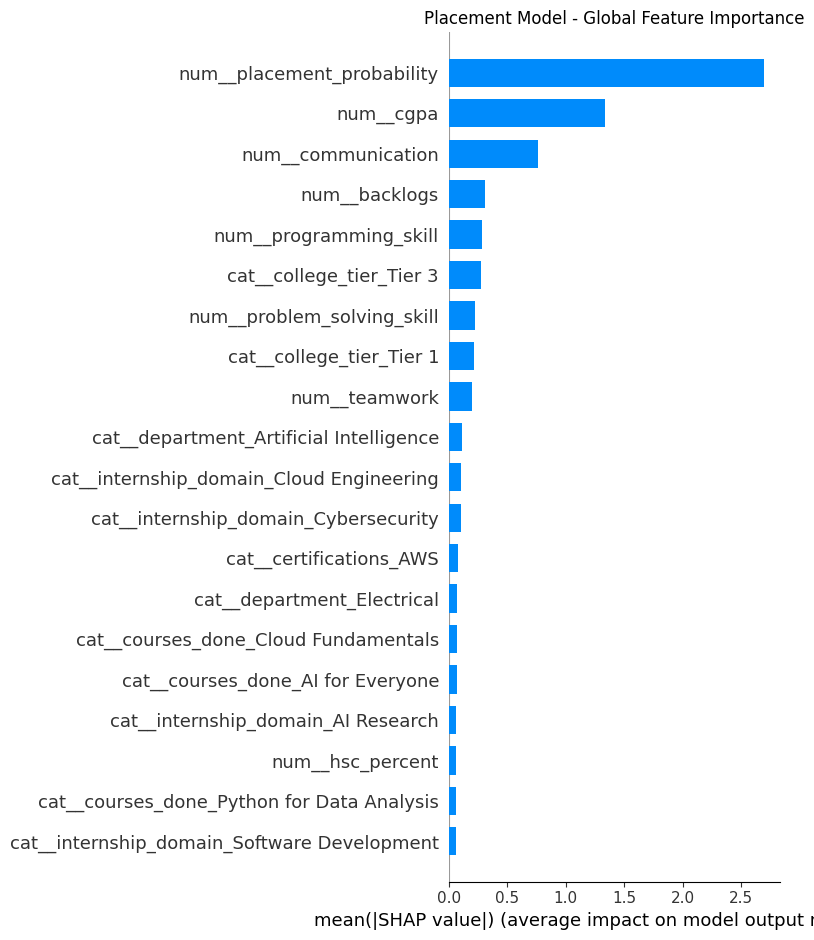

In [6]:
print("\nSHAP Analysis - Placement Model")

explainer_place = shap.Explainer(placement_model["clf"], X_trans_place)
shap_values_place = explainer_place(X_trans_place)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_place, features=X_trans_place, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Placement Model - Global Feature Importance")
plt.tight_layout()
plt.show()

In [7]:
print("\nSHAP Analysis - Career Model")

explainer_career = shap.TreeExplainer(career_model["clf"])
shap_values_career = explainer_career.shap_values(X_trans_career)

shap.summary_plot(shap_values_career, features=X_trans_career, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Career Model - Global Feature Importance")
plt.tight_layout()
plt.show()


SHAP Analysis - Career Model


ValueError: could not convert string to float: '[2.753125E-1,1.2125E-1,2.06875E-1,1.23125E-1,2.734375E-1]'

In [ ]:
print("\nExample: Single Student Explanation")

student = df.sample(1, random_state=99).drop([placement_target, career_target, "career_interest"], axis=1)
student_trans_place = placement_model["prep"].transform(student)
student_trans_career = career_model["prep"].transform(student)

In [ ]:
place_prob = placement_model["clf"].predict_proba(student_trans_place)[0][1]
print(f"Placement Probability: {place_prob*100:.2f}%")

In [ ]:
shap_values_student_place = explainer_place(student_trans_place)
shap.plots.waterfall(shap_values_student_place[0])

In [ ]:
career_probs = career_model["clf"].predict_proba(student_trans_career)[0]
career_classes = career_model["clf"].classes_
top3_idx = np.argsort(career_probs)[::-1][:3]

In [ ]:
print("\nTop-3 Career Predictions:")
for i in top3_idx:
    print(f" - {career_classes[i]}: {career_probs[i]*100:.1f}%")

shap_values_student_career = explainer_career.shap_values(student_trans_career)
shap.plots.waterfall(shap_values_student_career[np.argmax(career_probs)][0])